In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.append('..')

from minilearn.decomposition.pca import PCA
from minilearn.classifiers.logistic_regression import LogisticRegression
from minilearn.classifiers.knn import KNearestNeighbors
from minilearn.metrics.classification_metrics import accuracy, f1_score,classification_report
from sklearn.svm import SVC

os.makedirs('../outputs', exist_ok=True)

X_train_sc = np.load('../outputs/X_train_sc.npy')
X_test_sc  = np.load('../outputs/X_test_sc.npy')
y_train    = np.load('../outputs/y_train.npy')
y_test     = np.load('../outputs/y_test.npy')
feat_cols  = pd.read_csv('../outputs/feature_names.csv').iloc[:, 0].tolist()

EMOTION_NAMES = {
    1:'neutral', 2:'calm',    3:'happy',    4:'sad',
    5:'angry',   6:'fearful', 7:'disgust',  8:'surprised'
}
LABELS = [EMOTION_NAMES[i] for i in sorted(EMOTION_NAMES.keys())]

print(f'Train : {X_train_sc.shape}')
print(f'Test  : {X_test_sc.shape}')

Train : (1956, 112)
Test  : (496, 112)


In [4]:
# IMPORTANT: fit PCA on training data only — same rule as StandardScaler
# transform both train and test using the fitted PCA

pca_full = PCA(n_components=None)   # keep all components first
pca_full.fit(X_train_sc)

print(f'Total components : {len(pca_full.explained_variance_ratio_)}')
print(f'Top 5 explained variance:')
for i, var in enumerate(pca_full.explained_variance_ratio_[:5]):
    print(f'  PC{i+1}: {var*100:.2f}%')

Total components : 112
Top 5 explained variance:
  PC1: 18.46%
  PC2: 9.39%
  PC3: 6.07%
  PC4: 5.45%
  PC5: 4.51%


80% variance explained by 26 components
90% variance explained by 42 components
95% variance explained by 58 components
99% variance explained by 85 components


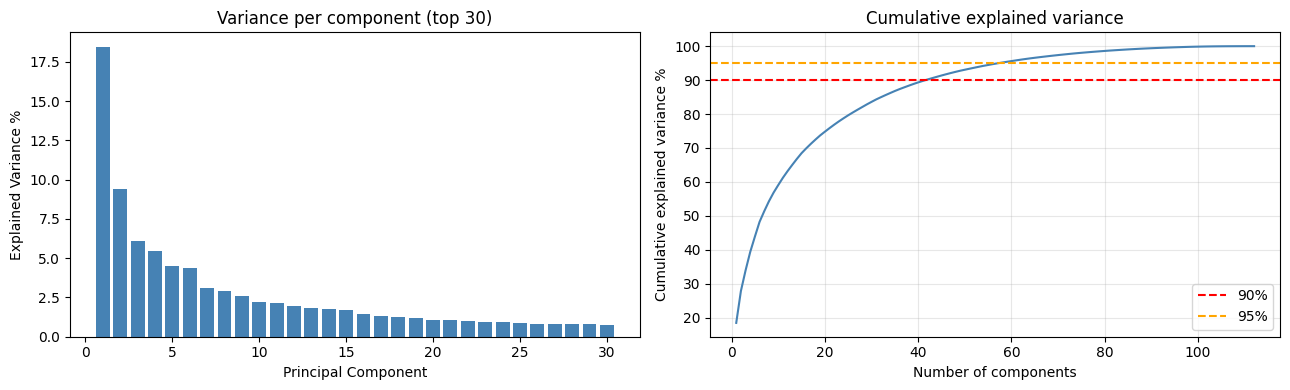

In [5]:
# cumulative explained variance — shows how many components you need
cumvar = pca_full.explained_variance_cumsum()

# find n_components for common thresholds
for threshold in [0.80, 0.90, 0.95, 0.99]:
    n = np.argmax(cumvar >= threshold) + 1
    print(f'{threshold*100:.0f}% variance explained by {n} components')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# individual explained variance
axes[0].bar(range(1, 31),
            pca_full.explained_variance_ratio_[:30] * 100,
            color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance %')
axes[0].set_title('Variance per component (top 30)')

# cumulative
axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100,
             color='steelblue', linewidth=1.5)
axes[1].axhline(90, color='red',    linestyle='--', label='90%')
axes[1].axhline(95, color='orange', linestyle='--', label='95%')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative explained variance %')
axes[1].set_title('Cumulative explained variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()

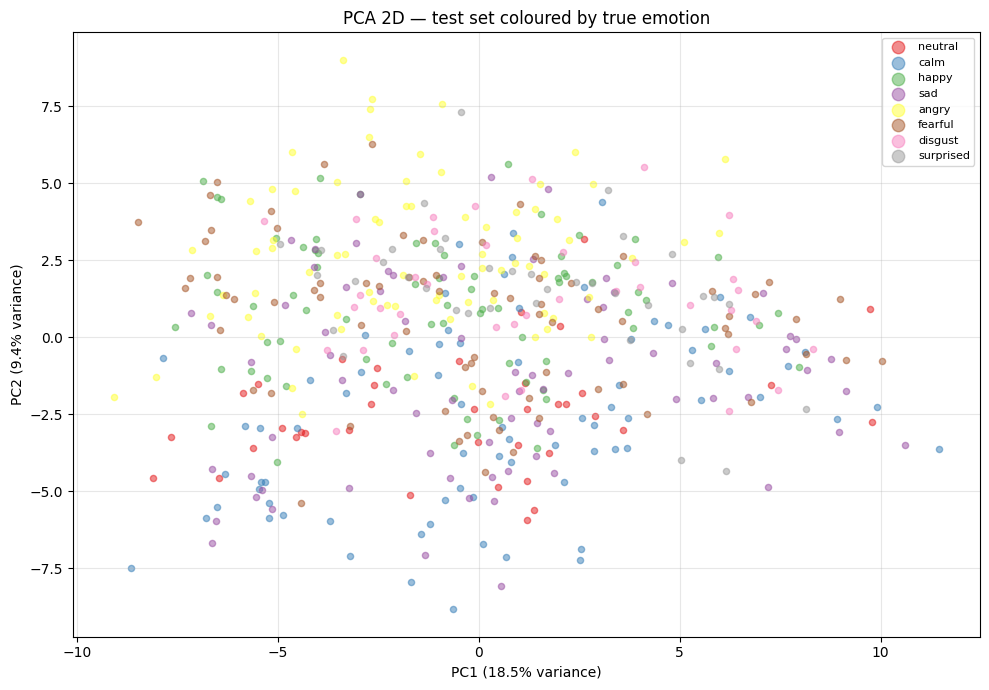

In [6]:
# project to 2D and colour by emotion
# shows how well emotions separate in PCA space
pca_2d  = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_sc)
X_test_2d  = pca_2d.transform(X_test_sc)

colors = plt.cm.Set1(np.linspace(0, 1, 8))

fig, ax = plt.subplots(figsize=(10, 7))
for i, label in enumerate(LABELS):
    mask = y_test == (i + 1)
    ax.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
               c=[colors[i]], alpha=0.5, s=20, label=label)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA 2D — test set coloured by true emotion')
ax.legend(fontsize=8, markerscale=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/pca_2d_emotions.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# key question: how many components do we need before performance drops?
# if 20 components gives same F1 as 112 → 92 features were redundant

n_components_list = [2, 5, 10, 20, 30, 50, 80, 112]
results           = []

print(f'{"n_components":>14}  {"var%":>6}  {"LR F1":>8}  {"KNN F1":>8}  {"SVM F1":>8}')
print('-' * 55)

for n in n_components_list:
    if n == 112:
        # baseline — no PCA
        X_tr = X_train_sc
        X_te = X_test_sc
        var_explained = 1.0
    else:
        pca  = PCA(n_components=n)
        X_tr = pca.fit_transform(X_train_sc)
        X_te = pca.transform(X_test_sc)
        var_explained = pca.explained_variance_cumsum()[-1]

    # logistic regression
    lr  = LogisticRegression(lr=0.1, n_iter=500, reg_lambda=0.01,
                              random_state=42)
    lr.fit(X_tr, y_train)
    f1_lr = f1_score(y_test, lr.predict(X_te), average='macro')

    # KNN
    knn = KNearestNeighbors(k=3, metric='manhattan')
    knn.fit(X_tr, y_train)
    f1_knn = f1_score(y_test, knn.predict(X_te), average='macro')

    # SVM (sklearn — best performing)
    svm = SVC(kernel='rbf', C=10, gamma=0.009, random_state=42)
    svm.fit(X_tr, y_train)
    f1_svm = f1_score(y_test, svm.predict(X_te), average='macro')

    results.append({
        'n_components'  : n,
        'var_explained' : var_explained,
        'LR F1'         : f1_lr,
        'KNN F1'        : f1_knn,
        'SVM F1'        : f1_svm
    })

    label = 'baseline (no PCA)' if n == 112 else f'{var_explained*100:.1f}% var'
    print(f'{n:>14}  {var_explained*100:>5.1f}%  {f1_lr:>8.4f}  {f1_knn:>8.4f}  {f1_svm:>8.4f}')

results_df = pd.DataFrame(results)

  n_components    var%     LR F1    KNN F1    SVM F1
-------------------------------------------------------
             2   27.8%    0.1782    0.1900    0.1769
             5   43.9%    0.2316    0.2557    0.2562
            10   59.1%    0.2826    0.3986    0.3705
            20   74.8%    0.3369    0.4507    0.5133
            30   83.6%    0.4684    0.5139    0.6083
            50   93.1%    0.5491    0.5525    0.6679
            80   98.6%    0.5986    0.5983    0.7297
           112  100.0%    0.6236    0.6009    0.7375


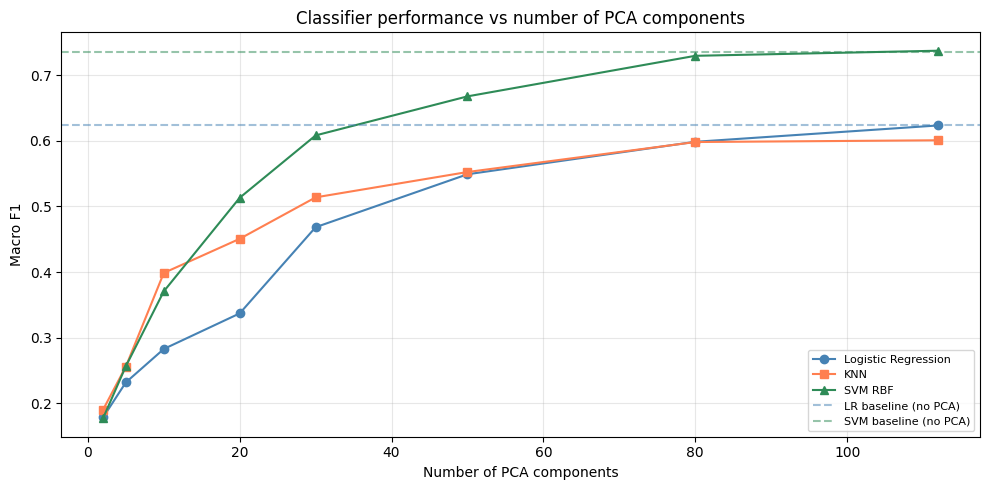

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(results_df['n_components'], results_df['LR F1'],
        marker='o', label='Logistic Regression', color='steelblue')
ax.plot(results_df['n_components'], results_df['KNN F1'],
        marker='s', label='KNN', color='coral')
ax.plot(results_df['n_components'], results_df['SVM F1'],
        marker='^', label='SVM RBF', color='seagreen')

# baseline horizontal lines
ax.axhline(0.6236, color='steelblue', linestyle='--',
           alpha=0.5, label='LR baseline (no PCA)')
ax.axhline(0.7359, color='seagreen',  linestyle='--',
           alpha=0.5, label='SVM baseline (no PCA)')

ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Macro F1')
ax.set_title('Classifier performance vs number of PCA components')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/pca_f1_vs_components.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# what do the top components represent?
# high loading on a feature = that feature drives this component

pca_final = PCA(n_components=20)
pca_final.fit(X_train_sc)

# top 5 features loading on PC1 and PC2
for pc_idx in range(3):
    loadings   = pca_final.components_[pc_idx]
    top_pos    = np.argsort(loadings)[::-1][:5]
    top_neg    = np.argsort(loadings)[:5]

    print(f'\nPC{pc_idx+1} ({pca_full.explained_variance_ratio_[pc_idx]*100:.1f}% variance):')
    print(f'  Positive loadings: {[feat_cols[i] for i in top_pos]}')
    print(f'  Negative loadings: {[feat_cols[i] for i in top_neg]}')


PC1 (18.5% variance):
  Positive loadings: ['chroma_mean_3', 'chroma_mean_7', 'chroma_mean_2', 'mfcc_mean_6', 'chroma_mean_8']
  Negative loadings: ['chroma_std_9', 'chroma_std_11', 'chroma_std_8', 'chroma_std_0', 'chroma_std_10']

PC2 (9.4% variance):
  Positive loadings: ['mfcc_d_std_0', 'mfcc_d2_std_5', 'mfcc_d2_std_1', 'mfcc_d2_std_0', 'mfcc_d2_std_8']
  Negative loadings: ['spec_ro_std', 'chroma_mean_5', 'spec_bw_std', 'mfcc_mean_1', 'spec_c_std']

PC3 (6.1% variance):
  Positive loadings: ['spec_c_std', 'spec_ro_std', 'spec_bw_std', 'chroma_std_1', 'chroma_std_2']
  Negative loadings: ['mfcc_mean_0', 'rms_mean', 'rms_std', 'mfcc_std_5', 'chroma_mean_5']


In [10]:
results_df.to_csv('../outputs/week12_pca_results.csv', index=False)

print('Week 12 complete')
print(f'\nKey finding:')
print(results_df[['n_components','var_explained','LR F1','SVM F1']].to_string(index=False))
print('\nSaved: week12_pca_results.csv')

Week 12 complete

Key finding:
 n_components  var_explained    LR F1   SVM F1
            2       0.278484 0.178208 0.176872
            5       0.438833 0.231631 0.256216
           10       0.590619 0.282636 0.370529
           20       0.747965 0.336939 0.513266
           30       0.835875 0.468373 0.608350
           50       0.930595 0.549100 0.667899
           80       0.985977 0.598604 0.729746
          112       1.000000 0.623556 0.737519

Saved: week12_pca_results.csv


## Key Finding

Full 112 features → SVM F1=0.7375, LR F1=0.6236
80 components (98.6% variance) → SVM F1=0.7297, LR F1=0.5986

**The last 32 features contribute almost zero performance gain.**
This confirms our Week 5 correlation analysis — adjacent MFCC 
coefficients are redundant. The 80-component model is nearly 
as good as the full model while being 28% smaller.

**For practical use:** 50 components (93.1% variance) gives 
SVM F1=0.6679 — a reasonable tradeoff between speed and accuracy.

**KNN insight:** KNN actually peaks at 50-80 components. Beyond 
that, adding more dimensions slightly hurts — this is the curse 
of dimensionality. In high dimensions, all points become 
equidistant and nearest-neighbor search loses meaning.